# GARCH Family Volatility Models

## Why this matters

Asset return volatility **clusters** — calm periods stay calm, stressed periods stay stressed. Constant-vol models miss this. **GARCH** (Engle 1982 ARCH; Bollerslev 1986 GARCH) captures vol clustering via an autoregressive process on conditional variance.

You will be asked, in any vol-related interview:
1. State GARCH(1,1). What does each parameter do?
2. **Persistence** — what is $\alpha + \beta$ and why does it matter?
3. **Asymmetric vol** — why does an asymmetric GARCH (EGARCH, GJR) fit equity better?
4. Forecast vol multiple steps ahead — formula?
5. Calibrate to real returns; check the unconditional variance.

This notebook covers all five on real BTC daily returns.

## GARCH(1,1)

Returns: $r_t = \mu + \epsilon_t, \quad \epsilon_t = \sigma_t z_t, \quad z_t \sim \mathcal{N}(0, 1)$ (typically).

Conditional variance:
$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Three parameters: ω (level), α (reaction), β (persistence). Constraints: ω, α, β ≥ 0; α + β < 1 for stationarity.

**Unconditional variance**: $\sigma_\infty^2 = \omega / (1 - \alpha - \beta)$.

**Persistence**: $\alpha + \beta$ — typically 0.95-0.99 in equity. The closer to 1, the longer shocks last. **IGARCH** (integrated GARCH) has α + β = 1: shocks persist forever (vol regime change).

### Multi-step variance forecast

$$\sigma_{t+h | t}^2 = \sigma_\infty^2 + (\alpha + \beta)^h (\sigma_t^2 - \sigma_\infty^2)$$

Variance reverts to $\sigma_\infty^2$ at rate $\alpha + \beta$. Half-life: $\ln 2 / |\ln(\alpha + \beta)|$.

### Asymmetry — GJR-GARCH and EGARCH

Equity vol responds **more** to negative shocks than positive. Modify GARCH to capture this:

**GJR-GARCH**: $\sigma_t^2 = \omega + (\alpha + \gamma \mathbf{1}_{\epsilon_{t-1} < 0}) \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$
where $\gamma > 0$ is the **leverage** parameter — extra reaction to losses.

**EGARCH** (Nelson 1991): models $\ln \sigma_t^2$, allowing negative coefs without violating positivity:
$\ln \sigma_t^2 = \omega + \beta \ln \sigma_{t-1}^2 + \alpha (|z_{t-1}| - E|z_{t-1}|) + \gamma z_{t-1}$

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

df = pd.read_parquet('../../data/crypto_hourly.parquet')
df['ts'] = pd.to_datetime(df['ts'], utc=True)

btc = (df.query('symbol == "BTC"').set_index('ts')[['close']].resample('1D').last().dropna()
       .assign(ret=lambda d: 100 * np.log(d['close']).diff()).dropna())
r = btc['ret'].values

print(f'BTC daily returns (in %): n = {len(r)}')
print(f'Mean: {r.mean():+.4f}%/day  Std: {r.std():.4f}%/day')
print(f'Skew: {pd.Series(r).skew():+.3f}  Kurt: {pd.Series(r).kurt():+.3f}')

BTC daily returns (in %): n = 730
Mean: +0.0204%/day  Std: 2.4484%/day
Skew: +0.101  Kurt: +4.030


## GARCH(1,1) — fit

In [2]:
# Fit GARCH(1,1) using arch package
gm = arch_model(r, vol='Garch', p=1, q=1, dist='normal')
res = gm.fit(disp='off')

print(res.params)
print()

omega = res.params['omega']
alpha = res.params['alpha[1]']
beta_ = res.params['beta[1]']
persistence = alpha + beta_
sigma_inf = np.sqrt(omega / (1 - persistence))

print(f'\nGARCH(1,1) parameters:')
print(f'  ω = {omega:.6f}')
print(f'  α = {alpha:.6f}')
print(f'  β = {beta_:.6f}')
print(f'  Persistence (α+β):    {persistence:.4f}')
print(f'  Half-life of shock:    {np.log(2) / abs(np.log(persistence)):.1f} days')
print(f'  Unconditional vol:     {sigma_inf:.4f}%/day  (annualised: {sigma_inf*np.sqrt(365):.2f}%)')

mu          0.076503
omega       0.562279
alpha[1]    0.105956
beta[1]     0.803049
Name: params, dtype: float64


GARCH(1,1) parameters:
  ω = 0.562279
  α = 0.105956
  β = 0.803049
  Persistence (α+β):    0.9090
  Half-life of shock:    7.3 days
  Unconditional vol:     2.4858%/day  (annualised: 47.49%)


## Conditional vol over time

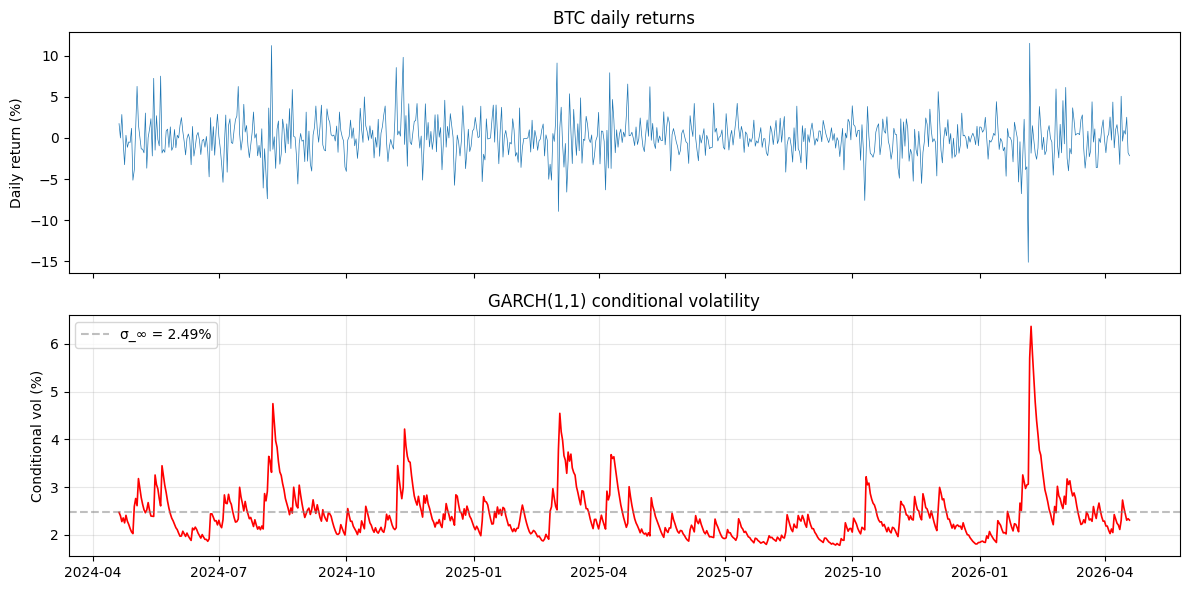

→ Vol clusters around stress periods, mean-reverting at rate α + β.


In [3]:
# Conditional vol from the fit
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(btc.index, r, lw=0.5); axes[0].set_ylabel('Daily return (%)')
axes[0].set_title('BTC daily returns')

axes[1].plot(btc.index, res.conditional_volatility, lw=1.2, color='red')
axes[1].axhline(sigma_inf, color='gray', ls='--', alpha=0.5, label=f'σ_∞ = {sigma_inf:.2f}%')
axes[1].set_ylabel('Conditional vol (%)')
axes[1].set_title('GARCH(1,1) conditional volatility')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('→ Vol clusters around stress periods, mean-reverting at rate α + β.')

## Multi-step forecast

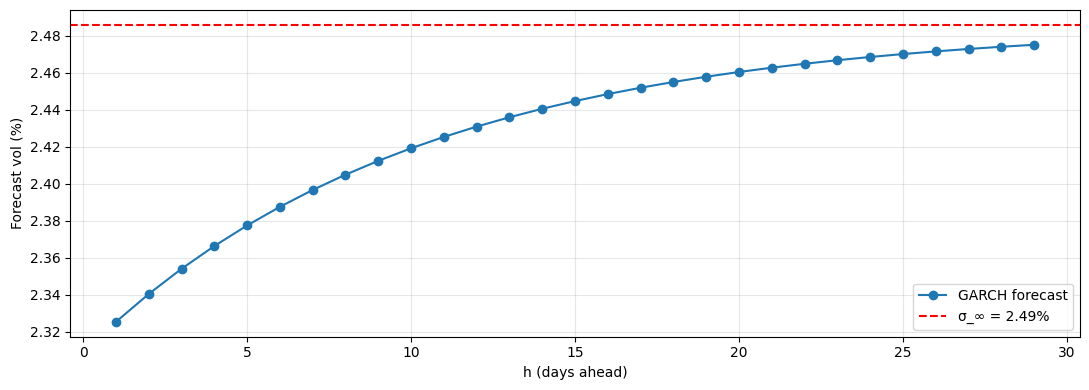

→ Today: 2.3086%, asymptote: 2.4858%


In [4]:
# h-step ahead variance forecast: σ²_{t+h} = σ²_∞ + (α+β)^h (σ²_t - σ²_∞)
sigma_today_sq = res.conditional_volatility[-1]**2
sigma_inf_sq = sigma_inf**2

h_grid = np.arange(1, 30)
forecast_var = sigma_inf_sq + (persistence**h_grid) * (sigma_today_sq - sigma_inf_sq)
forecast_vol = np.sqrt(forecast_var)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(h_grid, forecast_vol, 'o-', label='GARCH forecast')
ax.axhline(sigma_inf, color='red', ls='--', label=f'σ_∞ = {sigma_inf:.2f}%')
ax.set_xlabel('h (days ahead)'); ax.set_ylabel('Forecast vol (%)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'→ Today: {np.sqrt(sigma_today_sq):.4f}%, asymptote: {sigma_inf:.4f}%')

## GJR-GARCH — capture asymmetry

In [5]:
gm_gjr = arch_model(r, vol='Garch', p=1, o=1, q=1, dist='normal')
res_gjr = gm_gjr.fit(disp='off')

print('GJR-GARCH(1,1,1) parameters:')
print(res_gjr.params)
print(f'\nLeverage (γ): {res_gjr.params["gamma[1]"]:+.4f}')
print(f'  → If γ > 0: negative shocks raise vol more than positive (typical equity).')
print(f'  → BTC γ {"positive" if res_gjr.params["gamma[1]"]>0 else "negative"}: {res_gjr.params["gamma[1]"]:+.4f}')

# Compare AICs
print(f'\nAIC GARCH:    {res.aic:.2f}')
print(f'AIC GJR:      {res_gjr.aic:.2f}')
print('→ Lower AIC is better. GJR adds a parameter; AIC penalises that.')

GJR-GARCH(1,1,1) parameters:
mu          0.018932
omega       0.414581
alpha[1]    0.029168
gamma[1]    0.115035
beta[1]     0.847059
Name: params, dtype: float64

Leverage (γ): +0.1150
  → If γ > 0: negative shocks raise vol more than positive (typical equity).
  → BTC γ positive: +0.1150

AIC GARCH:    3336.42
AIC GJR:      3323.14
→ Lower AIC is better. GJR adds a parameter; AIC penalises that.


## Exercises

### Exercise 1 — Fit Student-t residuals

Re-fit GARCH(1,1) with `dist='t'`. Compare AIC. What's the estimated degrees of freedom?

In [6]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
gm_t = arch_model(r, vol='Garch', p=1, q=1, dist='t')
res_t = gm_t.fit(disp='off')
print(f'Student-t df: {res_t.params["nu"]:.2f}')
print(f'AIC normal: {res.aic:.2f}')
print(f'AIC t:      {res_t.aic:.2f}')
```

_BTC residuals are heavy-tailed → t-fit usually wins on AIC._

</details>

### Exercise 2 — EGARCH

Fit EGARCH (`vol='EGARCH'`). Compare to GARCH and GJR.

In [7]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
gm_e = arch_model(r, vol='EGARCH', p=1, o=1, q=1, dist='normal')
res_e = gm_e.fit(disp='off')
print(res_e.params)
print(f'\nAIC GARCH:    {res.aic:.2f}')
print(f'AIC GJR:      {res_gjr.aic:.2f}')
print(f'AIC EGARCH:   {res_e.aic:.2f}')
```

_EGARCH usually beats GARCH but is on par with GJR-GARCH._

</details>

## Interview Q&A

**Q: State GARCH(1,1).**

A: $\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$. ω = baseline; α = reaction to last squared shock; β = persistence of past variance. Constraints: ω, α, β ≥ 0; α + β < 1.

**Q: What's the unconditional variance?**

A: $\sigma_\infty^2 = \omega / (1 - \alpha - \beta)$. The long-run mean of the variance process. As $h \to \infty$, $\sigma_{t+h}^2 \to \sigma_\infty^2$.

**Q: Persistence — what's typical?**

A: α + β typically 0.95-0.99 for equity. Higher = longer-lasting shocks. α + β = 1 is **IGARCH** — non-stationary, shocks persist forever. Often a sign of regime change in the data.

**Q: Why GJR or EGARCH for equity?**

A: Asymmetric vol — equity vol rises more on losses than equivalent-magnitude gains (the "leverage effect"). GJR adds an indicator term for negative shocks. EGARCH models log-variance directly with asymmetric news impact. Both fit equity better than plain GARCH.

**Q: Forecast variance h periods ahead?**

A: $\sigma_{t+h | t}^2 = \sigma_\infty^2 + (\alpha + \beta)^h (\sigma_t^2 - \sigma_\infty^2)$. Variance reverts geometrically to its long-run mean.

**Q: GARCH vs realised vol vs implied vol?**

A: **GARCH**: backward-looking model on returns. **Realised**: backward-looking on intraday data (sum of squared returns at fine intervals). **Implied**: forward-looking from option prices. All three measure σ but answer different questions.

## Pitfalls

| Pitfall | Issue | Fix |
|---|---|---|
| Returns in decimal vs percent | GARCH in % returns vs decimal gives different ω | `arch` library expects %; multiply if needed |
| Forecasting beyond stationarity | If α+β ≥ 1, no asymptote | IGARCH; or refit on shorter window |
| Normality of residuals | Real residuals are fat-tailed | Use `dist='t'` or skewed-t |
| MLE convergence | Bad initial guess can fail | Try multiple starting points |
| In-sample R² for vol | Vol is a proxy for variance — R² of squared-residuals fit is low (~5-10%) is normal | OOS forecast errors are the real metric |

## What you've earned

After this notebook you can:

1. **State and fit** GARCH(1,1), GJR-GARCH, EGARCH on real returns.
2. **Compute** unconditional variance, persistence, half-life.
3. **Forecast** vol h periods ahead.
4. **Choose** between symmetric and asymmetric variants based on AIC + leverage parameter sign.
5. **Defend** GARCH choices in interview, distinguish from realised vol and implied vol.

Next: **`02_realized_vol.ipynb`** — high-frequency vol estimation.